In [6]:
#!git clone https://github.com/yuanzhumia0/CA1-2026025-Machine-Learning-for-Business.git

Cloning into 'CA1-2026025-Machine-Learning-for-Business'...


### Time-Based Data Split

The dataset was split based on time to avoid data leakage.

- **January to June:** Training set
- **July to September:** Validation set
- **October to December:** Test set

The training set is used to train the model. The validation set is used to compare models and tune parameters. The test set is used at the end to evaluate the final model on unseen future data.

In [3]:
#%pip install pandas pyarrow

In [1]:
import pandas as pd

df_jan = pd.read_parquet(
    "/Users/cat/Documents/GitHub/CA1-2026025-Machine-Learning-for-Business/yellow_tripdata_2025-01.parquet"
)

df_feb = pd.read_parquet(
    "/Users/cat/Documents/GitHub/CA1-2026025-Machine-Learning-for-Business/yellow_tripdata_2025-02.parquet"
)

df_mar = pd.read_parquet(
    "/Users/cat/Documents/GitHub/CA1-2026025-Machine-Learning-for-Business/yellow_tripdata_2025-03.parquet"
)

df_apr = pd.read_parquet(
    "/Users/cat/Documents/GitHub/CA1-2026025-Machine-Learning-for-Business/yellow_tripdata_2025-04.parquet"
)

df_may = pd.read_parquet(
    "/Users/cat/Documents/GitHub/CA1-2026025-Machine-Learning-for-Business/yellow_tripdata_2025-05.parquet"
)

df_jun = pd.read_parquet(
    "/Users/cat/Documents/GitHub/CA1-2026025-Machine-Learning-for-Business/yellow_tripdata_2025-06.parquet"
)


### Merge the data from January to June.

In [2]:
df = pd.concat(
    [df_jan, df_feb, df_mar, df_apr, df_may, df_jun],
    ignore_index=True
)

### Check how many rows 

In [3]:
df.head() 

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


### Check the number of columns.

In [4]:
df.shape[1]

20

Get all column names of the DataFrame.

In [5]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee',
 'cbd_congestion_fee']

In [6]:
print("January:", len(df_jan))
print("February:", len(df_feb))
print("March:", len(df_mar))
print("April:", len(df_apr))
print("May:", len(df_may))
print("June:", len(df_jun))

print("Total:", len(df))

January: 3475226
February: 3577543
March: 4145257
April: 3970553
May: 4591845
June: 4322960
Total: 24083384


### Combine January to June Data

The taxi data from January to June 2025 was combined into one dataset.

The combined dataset contains **24,083,384 trips** and will be used as the training dataset for the machine learning model.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24083384 entries, 0 to 24083383
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee         

### Dataset Information

The combined dataset from January to June 2025 contains **24,083,384 records** and **20 columns**.

The dataset includes numerical, categorical, and datetime variables.

The pickup and drop-off time columns are stored as datetime values, while most other columns are numerical. The dataset uses about **3.3 GB of memory**.

### Check missing values in each column

In [8]:
missing_values = pd.DataFrame({
    "Missing values": df.isna().sum(),
    "Missing (%)": (df.isna().mean() * 100).round(2)
})

missing_values

,Missing values,Missing (%)
VendorID,0,0.0
tpep_pickup_datetime,0,0.0
tpep_dropoff_datetime,0,0.0
passenger_count,5418601,22.5
trip_distance,0,0.0
RatecodeID,5418601,22.5
store_and_fwd_flag,5418601,22.5
PULocationID,0,0.0
DOLocationID,0,0.0
payment_type,0,0.0


### Missing Values

Most columns have no missing values.

However, `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, and `Airport_fee` contain missing values.

Each of these columns has **5,418,601 missing values**, which is about **22.5%** of the dataset.

These missing values need to be handled before building the machine learning model.

In [9]:
df[
    [
        "passenger_count",
        "RatecodeID",
        "store_and_fwd_flag",
        "congestion_surcharge",
        "Airport_fee"
    ]
].isna().all(axis=1).sum()

np.int64(5418601)

### Missing Value Pattern

The missing values in `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, and `Airport_fee` occur in the same records.

A total of **5,418,601 rows** have missing values in all five columns, which represents about **22.5%** of the dataset.

This shows that the missing values follow the same pattern. These records need to be checked before deciding whether to remove or keep them.

In [10]:
# Summary statistics for numerical columns
df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,24083384.0,1.838471,1.0,2.0,2.0,2.0,7.0,0.614304
tpep_pickup_datetime,24083384,2025-04-05 19:50:17.265199,2007-12-05 18:45:00,2025-02-20 22:31:47.750000,2025-04-07 10:24:38,2025-05-19 21:15:42,2025-06-30 23:59:59,NaN
tpep_dropoff_datetime,24083384,2025-04-05 20:06:46.641920,2007-12-05 19:02:00,2025-02-20 22:46:00,2025-04-07 10:42:52,2025-05-19 21:30:25.250000,2025-07-01 22:36:42,NaN
passenger_count,18664783.0,1.294859,0.0,1.0,1.0,1.0,9.0,0.736383
trip_distance,24083384.0,6.828011,0.0,1.02,1.8,3.49,386088.43,630.567645
RatecodeID,18664783.0,2.476726,1.0,1.0,1.0,1.0,99.0,11.567386
PULocationID,24083384.0,162.221438,1.0,116.0,161.0,233.0,265.0,65.979545
DOLocationID,24083384.0,161.784867,1.0,112.0,162.0,234.0,265.0,70.207735
payment_type,24083384.0,0.953637,0.0,1.0,1.0,1.0,5.0,0.741735
fare_amount,24083384.0,17.885351,-1807.6,8.6,13.5,21.84,863372.12,191.093627


### Summary Statistics

The summary statistics show the main features of the combined January to June dataset.

The average passenger count is about **1.29**, and the average trip distance is about **6.83 miles**.

The average fare amount is about **17.89**, while the average total amount is about **26.36**.

Some unusual values were found in the dataset. For example, there are negative fare values, very large trip distances, and some pickup dates outside the expected 2025 period.

These values may be outliers or data quality issues and should be checked during the data cleaning stage.

In [11]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Duplicate Records¶

I checked for rows with identical values in all columns. No duplicate rows were found, so no rows were removed in this step.

In [12]:
# Keep trips that started from January to June 2025
df_clean = df[
    (df["tpep_pickup_datetime"] >= "2025-01-01") &
    (df["tpep_pickup_datetime"] < "2025-07-01")
].copy()

print("Rows before filtering:", len(df))
print("Rows after filtering:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Rows before filtering: 24083384
Rows after filtering: 24083360
Rows removed: 24


### Date Range Filtering

The dataset was filtered to keep only trips from January to June 2025.

There were **24,083,384 rows** before filtering and **24,083,360 rows** after filtering.

Only **24 records** were outside the expected date range, so these records were removed.

In [13]:
# Calculate trip duration in minutes
df_clean["trip_duration_minutes"] = (
    df_clean["tpep_dropoff_datetime"] -
    df_clean["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# Display summary statistics
print(df_clean["trip_duration_minutes"].describe())

# Count trips with zero or negative duration
print(
    "\nTrips with duration <= 0:",
    (df_clean["trip_duration_minutes"] <= 0).sum()
)

count    2.408336e+07
mean     1.648961e+01
std      2.953693e+01
min     -5.147232e+04
25%      7.833333e+00
50%      1.283333e+01
75%      2.025000e+01
max      1.488077e+04
Name: trip_duration_minutes, dtype: float64

Trips with duration <= 0: 197119


### Trip Duration

The average trip duration is about **16.49 minutes**, while the median duration is about **12.83 minutes**.

There are **197,119 trips** with zero or negative duration. These records are not valid and should be removed during data cleaning.

The maximum trip duration is very large, which suggests that some unusually long trips may also need further checking.

In [14]:
# Remove trips with zero or negative duration
rows_before = len(df_clean)

df_clean = df_clean[
    df_clean["trip_duration_minutes"] > 0
].copy()

print("Rows removed:", rows_before - len(df_clean))
print("Rows remaining:", len(df_clean))

Rows removed: 197119
Rows remaining: 23886241


### Remove Invalid Trip Durations

Trips with zero or negative duration were removed because they do not represent valid trips.

A total of **197,119 records** were removed from the dataset.

The remaining records all have a positive trip duration.

In [15]:
# Check the upper percentiles of trip duration
df_clean["trip_duration_minutes"].quantile([0.95, 0.99, 0.999])

0.950     40.716667
0.990     67.333333
0.999    107.366667
Name: trip_duration_minutes, dtype: float64

### Trip Duration Outliers

Most trips have a reasonable duration.

- 95% of trips are shorter than **40.72 minutes**
- 99% are shorter than **67.33 minutes**
- 99.9% are shorter than **107.37 minutes**

This shows that very long trip durations are rare and may be outliers.

These unusually long trips should be checked before further analysis.

In [16]:
# Inspect the 10 longest trips
columns_to_check = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_duration_minutes",
    "trip_distance",
    "fare_amount",
    "total_amount"
]

df_clean.nlargest(10, "trip_duration_minutes")[columns_to_check]

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,total_amount
14429377,2025-04-01 09:00:28,2025-04-11 17:01:14,14880.766667,2.50,29.54,31.04
23683566,2025-06-21 12:19:33,2025-06-27 11:35:39,8596.100000,4.70,33.07,34.57
5131365,2025-02-17 23:46:36,2025-02-23 22:31:16,8564.666667,0.36,4.40,8.65
14538171,2025-04-05 19:23:15,2025-04-11 15:48:07,8424.866667,2.50,13.69,15.19
19648594,2025-05-29 06:24:25,2025-06-03 14:09:08,7664.716667,9.50,39.40,40.90
23676654,2025-06-21 09:42:22,2025-06-26 09:33:51,7191.483333,3.50,18.99,20.49
21056988,2025-06-13 00:15:50,2025-06-17 15:12:16,6656.433333,0.00,3.00,5.50
18449240,2025-05-30 22:57:55,2025-06-04 11:17:10,6499.250000,4.32,24.70,30.45
9268219,2025-03-22 03:11:02,2025-03-26 11:46:52,6275.833333,14.55,66.00,78.69
15213302,2025-05-01 13:07:55,2025-05-05 18:51:37,6103.700000,32.84,70.00,74.75


### Long Trip Duration Check

The longest trip durations were checked for possible outliers.

Most taxi trips are much shorter than 120 minutes. Trips longer than 120 minutes were considered unusually long and were removed from the dataset.

This helps reduce unrealistic or abnormal trip records before further analysis.

In [17]:
# Keep trips lasting up to 2 hours
rows_before = len(df_clean)

df_clean = df_clean[
    df_clean["trip_duration_minutes"] <= 120
].copy()

print("Rows removed:", rows_before - len(df_clean))
print("Rows remaining:", len(df_clean))

Rows removed: 15998
Rows remaining: 23870243


### Remove Long Trip Durations

Trips longer than **120 minutes (2 hours)** were treated as outliers and removed.

After removing invalid and unusually long trip durations, **23,870,243 records** remained in the dataset.

In [18]:
# Keep trips from January to June 2025
df_clean = df[
    (df["tpep_pickup_datetime"] >= "2025-01-01") &
    (df["tpep_pickup_datetime"] < "2025-07-01")
].copy()

# Calculate trip duration in minutes
df_clean["trip_duration_minutes"] = (
    df_clean["tpep_dropoff_datetime"] -
    df_clean["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# Keep durations greater than 0 and no more than 120 minutes
df_clean = df_clean[
    (df_clean["trip_duration_minutes"] > 0) &
    (df_clean["trip_duration_minutes"] <= 120)
].copy()

print("Rows remaining:", len(df_clean))

Rows remaining: 23870243


### Trip Duration Cleaning

The dataset was filtered to keep trips from January to June 2025.

Trip duration was calculated in minutes using the pickup and drop-off times.

Trips with zero or negative duration and trips longer than **120 minutes** were removed.

After cleaning, **23,870,243 records** remained in the dataset.

In [19]:
# Check non-positive distances and fares
print("Trips with distance <= 0:",
      (df_clean["trip_distance"] <= 0).sum())

print("Trips with fare <= 0:",
      (df_clean["fare_amount"] <= 0).sum())

print("Trips with total amount <= 0:",
      (df_clean["total_amount"] <= 0).sum())

# Check percentiles and maximum values
df_clean[["trip_distance", "fare_amount", "total_amount"]].quantile(
    [0.50, 0.95, 0.99, 0.999, 1.0]
)

Trips with distance <= 0: 655034
Trips with fare <= 0: 1332407
Trips with total amount <= 0: 449190


,trip_distance,fare_amount,total_amount
0.500,1.80,13.50,20.93
0.950,12.20,54.80,75.71
0.990,19.40,74.50,103.86
0.999,28.96,135.30,168.05
1.000,386088.43,863372.12,863380.37


### Distance and Fare Check

I checked the trip distance, fare amount, and total amount for invalid and extreme values.

There are **655,034 trips** with zero or negative distance, **1,332,407 trips** with zero or negative fare amount, and **449,190 trips** with zero or negative total amount.

Most values are within a reasonable range. For example, 99.9% of trip distances are below **28.96 miles**, fare amounts are below **135.30**, and total amounts are below **168.05**.

However, some extremely large maximum values were found, which may be outliers and need further cleaning.

In [20]:
# Keep trips with positive distances and charges
rows_before = len(df_clean)

df_clean = df_clean[
    (df_clean["trip_distance"] > 0) &
    (df_clean["fare_amount"] > 0) &
    (df_clean["total_amount"] > 0)
].copy()

print("Rows removed:", rows_before - len(df_clean))
print("Rows remaining:", len(df_clean))

Rows removed: 1865525
Rows remaining: 22004718


### Remove Invalid Distance and Fare Values

Trips with zero or negative `trip_distance`, `fare_amount`, or `total_amount` were removed.

A total of **1,865,525 records** were removed.

After this cleaning step, **22,004,718 records** remained in the dataset.

In [21]:
# Inspect the 10 longest distances
df_clean.nlargest(10, "trip_distance")[columns_to_check]

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,total_amount
15020907,2025-04-25 18:36:00,2025-04-25 18:56:00,20.0,386088.43,17.16,21.91
14458098,2025-04-02 18:40:00,2025-04-02 18:51:00,11.0,335783.69,15.18,19.93
14606995,2025-04-08 15:49:00,2025-04-08 16:25:00,36.0,302622.51,39.82,53.48
14942013,2025-04-22 06:10:00,2025-04-22 06:30:00,20.0,285554.64,28.51,40.20
11029221,2025-03-27 06:32:00,2025-03-27 06:42:00,10.0,281085.57,9.98,11.48
10911115,2025-03-22 05:11:00,2025-03-22 05:31:00,20.0,280125.56,21.53,23.03
3188501,2025-01-19 14:51:00,2025-01-19 14:58:00,7.0,276099.95,9.13,13.88
18881688,2025-05-09 17:38:00,2025-05-09 17:57:00,19.0,263103.98,17.17,21.92
22968940,2025-06-04 08:58:00,2025-06-04 09:19:00,21.0,261262.39,25.07,35.78
14881223,2025-04-19 16:31:00,2025-04-19 16:57:00,26.0,260485.80,30.66,35.41


### Extreme Trip Distance Check

The 10 trips with the largest trip distances were checked.

Some records contain extremely large distances, such as more than **300,000 miles**, while the trip duration is only around **10 to 30 minutes**.

The fare amounts for these trips are also relatively low, which suggests that these distance values are incorrect.

These records are treated as outliers and should be removed during data cleaning.

In [22]:
# Inspect the 10 highest fares
df_clean.nlargest(10, "fare_amount")[columns_to_check]

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,total_amount
1780915,2025-01-20 12:07:18,2025-01-20 12:12:42,5.400000,1.60,863372.12,863380.37
20860265,2025-06-11 14:41:03,2025-06-11 16:14:37,93.566667,20.60,325478.05,325528.45
5505988,2025-02-21 17:28:43,2025-02-21 17:53:04,24.350000,2.20,132531.36,132555.41
7904726,2025-03-09 00:34:23,2025-03-09 00:40:49,6.433333,1191.90,46263.88,46269.44
22430925,2025-06-26 15:06:34,2025-06-26 15:06:42,0.133333,17.30,2588.10,2593.85
14126041,2025-04-28 10:36:21,2025-04-28 10:36:50,0.483333,101.65,1047.40,1052.15
7225645,2025-03-02 15:38:24,2025-03-02 15:38:30,0.100000,0.03,999.00,1000.00
8918230,2025-03-18 21:06:34,2025-03-18 21:07:59,1.416667,0.60,977.00,992.06
6114222,2025-02-27 20:37:55,2025-02-27 20:38:03,0.133333,0.04,959.00,960.00
562143,2025-01-07 19:12:25,2025-01-07 19:14:04,1.650000,0.10,900.00,901.00


### Extreme Fare Amount Check

The 10 trips with the highest fare amounts were checked.

Some records have extremely high fares compared with their trip duration and distance.

For example, one trip lasted only about **5.4 minutes** and travelled **1.6 miles**, but the fare amount was over **863,000**.

Other trips also have fares close to **1,000** for very short distances and durations.

These values are likely incorrect and should be treated as outliers.

In [23]:
# Remove extremely large distances and charges
rows_before = len(df_clean)

df_clean = df_clean[
    (df_clean["trip_distance"] <= 1000) &
    (df_clean["fare_amount"] <= 1000) &
    (df_clean["total_amount"] <= 1000)
].copy()

print("Rows removed:", rows_before - len(df_clean))
print("Rows remaining:", len(df_clean))

Rows removed: 976
Rows remaining: 22003742


### Remove Extreme Outliers

Some records contained extremely large values for trip distance, fare amount, and total amount.

I removed records where `trip_distance`, `fare_amount`, or `total_amount` was greater than **1000**.

A total of **976 records** were removed.

After this step, **22,003,742 records** remained in the dataset.

In [24]:
# Calculate distance travelled per hour
df_clean["distance_per_hour"] = (
    df_clean["trip_distance"] /
    (df_clean["trip_duration_minutes"] / 60)
)

# Inspect the highest values
df_clean.nlargest(10, "distance_per_hour")[
    columns_to_check + ["distance_per_hour"]
]

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,total_amount,distance_per_hour
3012886,2025-01-10 13:01:23,2025-01-10 13:01:24,0.016667,18.78,2.90,60.20,67608.0
14588744,2025-04-07 12:04:29,2025-04-07 12:04:30,0.016667,16.53,2.90,44.42,59508.0
3405685,2025-01-29 07:01:14,2025-01-29 07:01:15,0.016667,16.27,1.45,53.05,58572.0
15154970,2025-04-30 14:04:10,2025-04-30 14:04:11,0.016667,13.31,2.90,38.08,47916.0
3382390,2025-01-27 12:01:56,2025-01-27 12:01:57,0.016667,13.22,2.90,39.15,47592.0
6529482,2025-02-11 12:02:05,2025-02-11 12:02:06,0.016667,12.51,2.90,33.35,45036.0
15126546,2025-04-29 00:04:18,2025-04-29 00:04:19,0.016667,12.28,2.90,36.02,44208.0
19993705,2025-06-03 15:25:23,2025-06-03 15:25:26,0.050000,35.70,3.00,4.50,42840.0
10117740,2025-03-30 06:25:26,2025-03-30 06:25:28,0.033333,21.00,70.00,97.09,37800.0
8041611,2025-03-10 17:17:03,2025-03-10 17:17:05,0.033333,20.38,70.00,103.13,36684.0


### Check Unrealistic Trip Speed

The average travel speed was calculated using trip distance and trip duration.

Some records have extremely high speeds. For example, one trip travelled **18.78 miles in about 1 second**, resulting in an average speed of more than **67,000 mph**.

These speeds are not realistic for taxi trips and suggest that some records have incorrect trip duration or distance values.

These records should be treated as outliers during data cleaning.

In [25]:
# Check the distribution of average speed
print(df_clean["distance_per_hour"].quantile(
    [0.50, 0.95, 0.99, 0.999]
))

# Count records above the proposed threshold
print(
    "\nTrips with distance per hour > 100:",
    (df_clean["distance_per_hour"] > 100).sum()
)

0.500     9.567929
0.950    24.199525
0.990    34.244633
0.999    46.021152
Name: distance_per_hour, dtype: float64

Trips with distance per hour > 100: 4705


### Average Speed Check

The average trip speed was calculated using trip distance and trip duration.

Most trips have reasonable average speeds. About **99.9% of trips have an average speed below 46.02 mph**.

However, **4,705 trips** have an average speed above **100 mph**. These speeds are unrealistic for normal taxi trips, so they are treated as outliers.

In [37]:
# Remove trips with average speeds above 100 mph
rows_before = len(df_clean)

df_clean = df_clean[
    df_clean["distance_per_hour"] <= 100
].copy()

print("Rows removed:", rows_before - len(df_clean))
print("Rows remaining:", len(df_clean))

Rows removed: 0
Rows remaining: 21999037


### Remove Unrealistic Trip Speeds

Trips with an average speed above **100 mph** were treated as unrealistic and removed.

A total of **4,705 records** were removed.

After this cleaning step, **21,999,037 records** remained in the dataset.

In [27]:
# Check missing values after cleaning
missing_after_cleaning = pd.DataFrame({
    "Missing values": df_clean.isna().sum(),
    "Missing (%)": (df_clean.isna().mean() * 100).round(2)
})

missing_after_cleaning

,Missing values,Missing (%)
VendorID,0,0.00
tpep_pickup_datetime,0,0.00
tpep_dropoff_datetime,0,0.00
passenger_count,4171348,18.96
trip_distance,0,0.00
RatecodeID,4171348,18.96
store_and_fwd_flag,4171348,18.96
PULocationID,0,0.00
DOLocationID,0,0.00
payment_type,0,0.00


### Missing Values After Cleaning

After the main data cleaning steps, I checked the missing values again.

Most columns have no missing values.

However, `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, and `Airport_fee` still contain missing values.

Each of these columns has **4,171,348 missing values**, which is about **18.96%** of the cleaned dataset.

These missing values still need to be handled before building the machine learning model.

In [28]:
# Check passenger counts, including missing values
df_clean["passenger_count"].value_counts(dropna=False).sort_index()

passenger_count
0.0      132907
1.0    14162152
2.0     2458528
3.0      559072
4.0      352723
5.0      102850
6.0       59419
7.0           8
8.0          24
9.0           6
NaN     4171348
Name: count, dtype: int64

### Passenger Count Check

The passenger count was checked, including missing values.

Most trips have **1 passenger**, followed by trips with **2 passengers**.

There are **132,907 trips** with a passenger count of 0, and **4,171,348 records** have missing passenger count values.

Very high passenger counts such as 7, 8, and 9 are rare.

The missing and unusual passenger count values need to be considered before modelling.

In [38]:
# Select columns for further analysis
analysis_columns = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "trip_distance",
    "fare_amount",
    "total_amount",
    "trip_duration_minutes",
    "distance_per_hour"
]

df_analysis = df_clean[analysis_columns].copy()

In [39]:
print("Final shape:", df_analysis.shape)

print("\nMissing values:")
print(df_analysis.isna().sum())

df_analysis[
    [
        "trip_distance",
        "fare_amount",
        "total_amount",
        "trip_duration_minutes",
        "distance_per_hour"
    ]
].describe().T

Final shape: (21999037, 10)

Missing values:
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
PULocationID             0
DOLocationID             0
payment_type             0
trip_distance            0
fare_amount              0
total_amount             0
trip_duration_minutes    0
distance_per_hour        0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
trip_distance,21999037.0,3.362690,4.194915,0.010000,1.080000,1.830000,3.510000,119.62
fare_amount,21999037.0,19.320621,16.720660,0.010000,9.300000,14.200000,22.440000,999.00
total_amount,21999037.0,28.114430,20.925624,1.010000,16.450000,21.500000,30.350000,1000.00
trip_duration_minutes,21999037.0,16.214508,12.711414,0.016667,7.966667,12.850000,20.233333,120.00
distance_per_hour,21999037.0,11.138022,6.271151,0.005050,7.208818,9.566434,13.067616,100.00


### Final Data Check

After cleaning and selecting the main columns, the final dataset contains **21,999,037 records** and **10 variables**.

There are no missing values in the selected columns.

The average trip distance is about **3.36 miles**, and the average trip duration is about **16.21 minutes**.

The average fare amount is about **19.32**, while the average total amount is about **28.11**.

The average travel speed is about **11.14 mph**.

The dataset is now ready for further analysis and machine learning.

In [40]:
df_jul = pd.read_parquet(
    "/Users/cat/Documents/GitHub/CA1-2026025-Machine-Learning-for-Business/yellow_tripdata_2025-07.parquet"
)

df_aug = pd.read_parquet(
    "/Users/cat/Documents/GitHub/CA1-2026025-Machine-Learning-for-Business/yellow_tripdata_2025-08.parquet"
)

df_sep = pd.read_parquet(
    "/Users/cat/Documents/GitHub/CA1-2026025-Machine-Learning-for-Business/yellow_tripdata_2025-09.parquet"
)

In [41]:
df_validation = pd.concat(
    [df_jul, df_aug, df_sep],
    ignore_index=True
)
print("Validation shape:", df_validation.shape)

Validation shape: (11724069, 20)


### Validation Dataset

The July to September 2025 taxi data was combined to create the validation dataset.

The validation dataset contains **11,724,069 records** and **20 columns**.

This dataset will be cleaned using the same rules as the training data before it is used to evaluate the machine learning model.

In [42]:
# Check validation dataset information
df_validation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11724069 entries, 0 to 11724068
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee         

In [43]:
# Check missing values in validation data
missing_validation = pd.DataFrame({
    "Missing values": df_validation.isna().sum(),
    "Missing (%)": (df_validation.isna().mean() * 100).round(2)
})

missing_validation

,Missing values,Missing (%)
VendorID,0,0.00
tpep_pickup_datetime,0,0.00
tpep_dropoff_datetime,0,0.00
passenger_count,2992184,25.52
trip_distance,0,0.00
RatecodeID,2992184,25.52
store_and_fwd_flag,2992184,25.52
PULocationID,0,0.00
DOLocationID,0,0.00
payment_type,0,0.00


### Validation Data Check

The validation dataset contains **11,724,069 records** and **20 columns**.

The data types are consistent with the training dataset, including numerical, categorical, and datetime variables.

Most columns have no missing values. However, `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, and `Airport_fee` contain missing values.

Each of these columns has **2,992,184 missing values**, which is about **25.52%** of the validation dataset.

The validation data will be cleaned using the same rules as the training data.

In [44]:
# Keep trips from July to September 2025
df_validation_clean = df_validation[
    (df_validation["tpep_pickup_datetime"] >= "2025-07-01") &
    (df_validation["tpep_pickup_datetime"] < "2025-10-01")
].copy()

print("Rows before filtering:", len(df_validation))
print("Rows after filtering:", len(df_validation_clean))
print("Rows removed:", len(df_validation) - len(df_validation_clean))

Rows before filtering: 11724069
Rows after filtering: 11724060
Rows removed: 9


### Validation Date Range Filtering

The validation dataset was filtered to keep only trips from July to September 2025.

There were **11,724,069 records** before filtering and **11,724,060 records** after filtering.

Only **9 records** were outside the expected date range and were removed.

In [45]:
# Calculate trip duration in minutes
df_validation_clean["trip_duration_minutes"] = (
    df_validation_clean["tpep_dropoff_datetime"] -
    df_validation_clean["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# Check trip duration
print(df_validation_clean["trip_duration_minutes"].describe())

print(
    "\nTrips with duration <= 0:",
    (df_validation_clean["trip_duration_minutes"] <= 0).sum()
)

count    1.172406e+07
mean     1.769639e+01
std      2.754210e+01
min     -2.088833e+02
25%      8.300000e+00
50%      1.388333e+01
75%      2.206667e+01
max      1.129583e+04
Name: trip_duration_minutes, dtype: float64

Trips with duration <= 0: 161076


### Validation Trip Duration

The average trip duration is about **17.70 minutes**, and the median duration is about **13.88 minutes**.

There are **161,076 trips** with zero or negative duration. These records are not valid and need to be removed.

Some trips also have very long durations, so the same **120-minute limit** used for the training data will be applied to the validation dataset.

In [46]:
# Keep valid trip durations
rows_before = len(df_validation_clean)

df_validation_clean = df_validation_clean[
    (df_validation_clean["trip_duration_minutes"] > 0) &
    (df_validation_clean["trip_duration_minutes"] <= 120)
].copy()

print("Rows removed:", rows_before - len(df_validation_clean))
print("Rows remaining:", len(df_validation_clean))

Rows removed: 169630
Rows remaining: 11554430


### Validation Trip Duration Cleaning

Trips with zero or negative duration and trips longer than **120 minutes** were removed from the validation dataset.

A total of **169,630 records** were removed.

After this cleaning step, **11,554,430 records** remained in the validation dataset.

In [47]:
# Check non-positive distances and fares in validation data
print(
    "Trips with distances<=0:",
    (df_validation_clean["trip_distance"]<=0).sum()
)
print(
    "Trips with fare<=0:",
    (df_validation_clean["fare_amount"]<=0).sum()
)
print(
    "Trips with total amount<=0:",
    (df_validation_clean["total_amount"]<=0).sum()
)

Trips with distances<=0: 348871
Trips with fare<=0: 765177
Trips with total amount<=0: 244352


In [48]:
df_validation_clean[
    ["trip_distance","fare_amount","total_amount"]
].quantile([0.50,0.95,0.99,0.999,1.0])

,trip_distance,fare_amount,total_amount
0.500,1.95,14.20,21.45
0.950,13.56,60.00,78.59
0.990,19.76,80.70,105.18
0.999,30.59,152.80,186.29
1.000,397994.37,323800.27,323820.17


### Validation Distance and Fare Check

The validation dataset was checked for invalid distance and fare values.

There are **348,871 trips** with zero or negative trip distance, **765,177 trips** with zero or negative fare amount, and **244,352 trips** with zero or negative total amount.

Most values are within a reasonable range, but some very large maximum values were also found.

The same cleaning rules used for the training dataset will be applied to the validation data.

In [49]:
# Keep trips with positive distances and charges
rows_before = len(df_validation_clean)

df_validation_clean = df_validation_clean[
    (df_validation_clean["trip_distance"] > 0) &
    (df_validation_clean["fare_amount"] > 0) &
    (df_validation_clean["total_amount"] > 0)
].copy()

print("Rows removed:", rows_before - len(df_validation_clean))
print("Rows remaining:", len(df_validation_clean))

Rows removed: 1048541
Rows remaining: 10505889


### Remove Invalid Distance and Fare Values

Trips with zero or negative trip distance, fare amount, or total amount were removed from the validation dataset.

A total of **1,048,541 records** were removed.

After this cleaning step, **10,505,889 records** remained in the validation dataset.

In [50]:
# Remove extremely large distances and charges
rows_before = len(df_validation_clean)

df_validation_clean = df_validation_clean[
    (df_validation_clean["trip_distance"] <= 1000) &
    (df_validation_clean["fare_amount"] <= 1000) &
    (df_validation_clean["total_amount"] <= 1000)
].copy()

print("Rows removed:", rows_before - len(df_validation_clean))
print("Rows remaining:", len(df_validation_clean))

Rows removed: 374
Rows remaining: 10505515


### Remove Extreme Outliers

Extremely large values in trip distance, fare amount, and total amount were removed from the validation dataset.

A total of **374 records** were removed.

After this cleaning step, **10,505,515 records** remained in the validation dataset.

In [51]:
# Calculate average speed for validation data
df_validation_clean["distance_per_hour"] = (
    df_validation_clean["trip_distance"] /
    (df_validation_clean["trip_duration_minutes"] / 60)
)

# Check speed distribution
print(
    df_validation_clean["distance_per_hour"].quantile(
        [0.50, 0.95, 0.99, 0.999]
    )
)

print(
    "\nTrips with distance per hour > 100:",
    (df_validation_clean["distance_per_hour"] > 100).sum()
)

0.500     9.697586
0.950    24.651712
0.990    34.506663
0.999    46.867742
Name: distance_per_hour, dtype: float64

Trips with distance per hour > 100: 2344


### Validation Average Speed Check

Most trips in the validation dataset have reasonable average speeds.

About **99.9% of trips have an average speed below 46.87 mph**.

There are **2,344 trips** with an average speed above **100 mph**. These trips are treated as unrealistic outliers and will be removed using the same rule as the training dataset.

In [52]:
# Remove trips with unrealistic average speed
rows_before = len(df_validation_clean)

df_validation_clean = df_validation_clean[
    df_validation_clean["distance_per_hour"] <= 100
].copy()

print("Rows removed:", rows_before - len(df_validation_clean))
print("Rows remaining:", len(df_validation_clean))

Rows removed: 2344
Rows remaining: 10503171


### Remove Unrealistic Trip Speeds

Trips with an average speed above **100 mph** were treated as unrealistic outliers.

A total of **2,344 trips** were identified above this threshold and were removed during the validation data cleaning process.

After this cleaning step, **10,503,171 records** remained in the validation dataset.

In [53]:
# Select the same columns used in the training dataset
validation_columns = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "trip_distance",
    "fare_amount",
    "total_amount",
    "trip_duration_minutes",
    "distance_per_hour"
]

df_validation_analysis = df_validation_clean[validation_columns].copy()

print("Final validation shape:", df_validation_analysis.shape)

print("\nMissing values:")
print(df_validation_analysis.isna().sum())

Final validation shape: (10503171, 10)

Missing values:
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
PULocationID             0
DOLocationID             0
payment_type             0
trip_distance            0
fare_amount              0
total_amount             0
trip_duration_minutes    0
distance_per_hour        0
dtype: int64


### Final Validation Dataset Check

After cleaning and selecting the same columns used in the training dataset, the final validation dataset contains **10,503,171 records** and **10 variables**.

There are no missing values in the selected columns.

The validation dataset now has the same structure as the training dataset and is ready for model evaluation.

In [54]:
df_oct = pd.read_parquet(
    "/Users/cat/Documents/GitHub/CA1-2026025-Machine-Learning-for-Business/yellow_tripdata_2025-10.parquet"
)

df_nov = pd.read_parquet(
    "/Users/cat/Documents/GitHub/CA1-2026025-Machine-Learning-for-Business/yellow_tripdata_2025-11.parquet"
)

df_dec = pd.read_parquet(
    "/Users/cat/Documents/GitHub/CA1-2026025-Machine-Learning-for-Business/yellow_tripdata_2025-12.parquet"
)

df_test = pd.concat(
    [df_oct, df_nov, df_dec],
    ignore_index=True
)

print("Test shape:", df_test.shape)

Test shape: (12915149, 20)


### Test Dataset

The October to December 2025 data was combined into the test dataset.

The test dataset contains **12,915,149 records** and **20 columns**.

In [55]:
# Check test dataset information
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12915149 entries, 0 to 12915148
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee         

In [56]:
# Check missing values in test data
missing_test = pd.DataFrame({
    "Missing values": df_test.isna().sum(),
    "Missing (%)": (df_test.isna().mean() * 100).round(2)
})

missing_test

,Missing values,Missing (%)
VendorID,0,0.00
tpep_pickup_datetime,0,0.00
tpep_dropoff_datetime,0,0.00
passenger_count,3201109,24.79
trip_distance,0,0.00
RatecodeID,3201109,24.79
store_and_fwd_flag,3201109,24.79
PULocationID,0,0.00
DOLocationID,0,0.00
payment_type,0,0.00


### Test Data Check

The test dataset contains **12,915,149 records** and **20 columns**.

Most columns have no missing values.

However, `passenger_count`, `RatecodeID`, `store_and_fwd_flag`, `congestion_surcharge`, and `Airport_fee` have **3,201,109 missing values**, which is about **24.79%** of the test dataset.

The same cleaning rules used for the training and validation datasets will be applied to the test data.

In [57]:
# Keep trips from October to December 2025
df_test_clean = df_test[
    (df_test["tpep_pickup_datetime"] >= "2025-10-01") &
    (df_test["tpep_pickup_datetime"] < "2026-01-01")
].copy()

print("Rows before filtering:", len(df_test))
print("Rows after filtering:", len(df_test_clean))
print("Rows removed:", len(df_test) - len(df_test_clean))

Rows before filtering: 12915149
Rows after filtering: 12915136
Rows removed: 13


In [58]:
# Calculate trip duration in minutes
df_test_clean["trip_duration_minutes"] = (
    df_test_clean["tpep_dropoff_datetime"] -
    df_test_clean["tpep_pickup_datetime"]
).dt.total_seconds() / 60

# Check trip duration
print(df_test_clean["trip_duration_minutes"].describe())

print(
    "\nTrips with duration <= 0:",
    (df_test_clean["trip_duration_minutes"] <= 0).sum()
)

count    1.291514e+07
mean     1.866195e+01
std      2.646960e+01
min     -7.073167e+02
25%      8.600000e+00
50%      1.451667e+01
75%      2.331667e+01
max      8.611867e+03
Name: trip_duration_minutes, dtype: float64

Trips with duration <= 0: 188109


### Test Trip Duration

The test dataset was filtered to keep trips from October to December 2025.

Only **13 records** were outside the expected date range and were removed.

The average trip duration is about **18.66 minutes**, and the median is about **14.52 minutes**.

There are **188,109 trips** with zero or negative duration, so these records need to be removed.

In [59]:
# Keep valid trip durations
rows_before = len(df_test_clean)

df_test_clean = df_test_clean[
    (df_test_clean["trip_duration_minutes"] > 0) &
    (df_test_clean["trip_duration_minutes"] <= 120)
].copy()

print("Rows removed:", rows_before - len(df_test_clean))
print("Rows remaining:", len(df_test_clean))

Rows removed: 203059
Rows remaining: 12712077


### Test Trip Duration Cleaning

Trips with zero or negative duration and trips longer than **120 minutes** were removed from the test dataset.

A total of **203,059 records** were removed.

After this cleaning step, **12,712,077 records** remained in the test dataset.

In [60]:
# Check non-positive distances and fares in test data
print(
    "Trips with distance <= 0:",
    (df_test_clean["trip_distance"] <= 0).sum()
)

print(
    "Trips with fare <= 0:",
    (df_test_clean["fare_amount"] <= 0).sum()
)

print(
    "Trips with total amount <= 0:",
    (df_test_clean["total_amount"] <= 0).sum()
)

# Check percentiles and maximum values
df_test_clean[
    ["trip_distance", "fare_amount", "total_amount"]
].quantile(
    [0.50, 0.95, 0.99, 0.999, 1.0]
)

Trips with distance <= 0: 382386
Trips with fare <= 0: 771183
Trips with total amount <= 0: 285903


,trip_distance,fare_amount,total_amount
0.500,1.87,14.2,22.05000
0.950,12.90,60.4,79.14000
0.990,19.50,83.0,105.78000
0.999,29.80,147.2,179.15924
1.000,322576.17,1508.7,1514.45000


### Test Distance and Fare Check

The test dataset was checked for invalid distance and fare values.

There are **382,386 trips** with zero or negative trip distance, **771,183 trips** with zero or negative fare amount, and **285,903 trips** with zero or negative total amount.

Some very large values were also found, so the same cleaning rules used for the training and validation datasets will be applied.

In [61]:
# Keep trips with positive distances and charges
rows_before = len(df_test_clean)

df_test_clean = df_test_clean[
    (df_test_clean["trip_distance"] > 0) &
    (df_test_clean["fare_amount"] > 0) &
    (df_test_clean["total_amount"] > 0)
].copy()

print("Rows removed:", rows_before - len(df_test_clean))
print("Rows remaining:", len(df_test_clean))

Rows removed: 1088914
Rows remaining: 11623163


### Remove Invalid Distance and Fare Values

Trips with zero or negative trip distance, fare amount, or total amount were removed from the test dataset.

A total of **1,088,914 records** were removed.

After this cleaning step, **11,623,163 records** remained in the test dataset.

In [63]:
# Remove extremely large distances and charges
rows_before = len(df_test_clean)

df_test_clean = df_test_clean[
    (df_test_clean["trip_distance"] <= 1000) &
    (df_test_clean["fare_amount"] <= 1000) &
    (df_test_clean["total_amount"] <= 1000)
].copy()

print("Rows removed:", rows_before - len(df_test_clean))
print("Rows remaining:", len(df_test_clean))

Rows removed: 340
Rows remaining: 11622823


### Remove Extreme Outliers

Extremely large values in trip distance, fare amount, and total amount were removed from the test dataset.

A total of **340 records** were removed.

After this cleaning step, **11,622,823 records** remained in the test dataset.

In [64]:
# Calculate average speed for test data
df_test_clean["distance_per_hour"] = (
    df_test_clean["trip_distance"] /
    (df_test_clean["trip_duration_minutes"] / 60)
)

# Check speed distribution
print(
    df_test_clean["distance_per_hour"].quantile(
        [0.50, 0.95, 0.99, 0.999]
    )
)

print(
    "\nTrips with distance per hour > 100:",
    (df_test_clean["distance_per_hour"] > 100).sum()
)

0.500     8.930710
0.950    23.549957
0.990    34.112332
0.999    46.929880
Name: distance_per_hour, dtype: float64

Trips with distance per hour > 100: 2547


### Test Average Speed Check

Most trips in the test dataset have reasonable average speeds.

About **99.9% of trips have an average speed below 46.93 mph**.

There are **2,547 trips** with an average speed above **100 mph**, so these records will be treated as unrealistic outliers.

In [65]:
# Remove trips with unrealistic average speed
rows_before = len(df_test_clean)
df_test_clean=df_test_clean[
    df_test_clean["distance_per_hour"]<=100
].copy()
print("Rows removed",rows_before - len(df_test_clean))
print("Rows remaining",len(df_test_clean))

Rows removed 2547
Rows remaining 11620276


### Remove Unrealistic Trip Speeds

Trips with an average speed above **100 mph** were removed from the test dataset.

A total of **2,547 records** were removed.

After this cleaning step, **11,620,276 records** remained in the test dataset.

In [66]:
# Select the same columns used in training and validation
test_columns = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "trip_distance",
    "fare_amount",
    "total_amount",
    "trip_duration_minutes",
    "distance_per_hour"
]

df_test_analysis = df_test_clean[test_columns].copy()

print("Final test shape:", df_test_analysis.shape)

print("\nMissing values:")
print(df_test_analysis.isna().sum())

Final test shape: (11620276, 10)

Missing values:
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
PULocationID             0
DOLocationID             0
payment_type             0
trip_distance            0
fare_amount              0
total_amount             0
trip_duration_minutes    0
distance_per_hour        0
dtype: int64


### Final Test Dataset Check

After cleaning and selecting the same columns used in the training and validation datasets, the final test dataset contains **11,620,276 records** and **10 variables**.

There are no missing values in the selected columns.

The test dataset is now ready for final model evaluation.

## Machine Learning Model

The aim of this model is to predict the **total amount of a taxi trip**.

The target variable is `total_amount`.**Target = total_amount**

The model will use trip information such as distance, duration, pickup and drop-off locations, payment type, and trip time to make the prediction.

The January to June data will be used for training, July to September for validation, and October to December for final testing.

In [70]:
# Create time features for training data
df_analysis["pickup_hour"] = df_analysis["tpep_pickup_datetime"].dt.hour
df_analysis["pickup_dayofweek"] = df_analysis["tpep_pickup_datetime"].dt.dayofweek
df_analysis["pickup_month"] = df_analysis["tpep_pickup_datetime"].dt.month

df_analysis[
    [
        "tpep_pickup_datetime",
        "pickup_hour",
        "pickup_dayofweek",
        "pickup_month"
    ]
].head()

,tpep_pickup_datetime,pickup_hour,pickup_dayofweek,pickup_month
0,2025-01-01 00:18:38,0,2,1
1,2025-01-01 00:32:40,0,2,1
2,2025-01-01 00:44:04,0,2,1
3,2025-01-01 00:14:27,0,2,1
4,2025-01-01 00:21:34,0,2,1


### Time Features

The pickup datetime was used to create new time features for the machine learning model.

The new features include pickup hour, day of the week, and month.

These features may help the model understand how taxi trip costs change at different times.

In [71]:
# Define features and target for training data
feature_columns = [
    "PULocationID",
    "DOLocationID",
    "payment_type",
    "trip_distance",
    "trip_duration_minutes",
    "distance_per_hour",
    "pickup_hour",
    "pickup_dayofweek",
    "pickup_month"
]

X_train = df_analysis[feature_columns]
y_train = df_analysis["total_amount"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (21999037, 9)
y_train shape: (21999037,)


### Training Features and Target

The training dataset contains **21,999,037 records**.

The model uses **9 input features** to predict `total_amount`.

`X_train` contains the input features, while `y_train` contains the target variable.

In [72]:
# Create time features for validation data
df_validation_analysis["pickup_hour"] = (
    df_validation_analysis["tpep_pickup_datetime"].dt.hour
)

df_validation_analysis["pickup_dayofweek"] = (
    df_validation_analysis["tpep_pickup_datetime"].dt.dayofweek
)

df_validation_analysis["pickup_month"] = (
    df_validation_analysis["tpep_pickup_datetime"].dt.month
)

In [73]:
# Define features and target for validation data
X_validation = df_validation_analysis[feature_columns]
y_validation = df_validation_analysis["total_amount"]

print("X_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

X_validation shape: (10503171, 9)
y_validation shape: (10503171,)


### Validation Features and Target

The validation dataset contains **10,503,171 records**.

The same **9 input features** used in the training dataset were also used for validation.

`X_validation` contains the input features, while `y_validation` contains the `total_amount` target variable.

In [75]:
# Create time features for test data
df_test_analysis["pickup_hour"] = (
    df_test_analysis["tpep_pickup_datetime"].dt.hour
)

df_test_analysis["pickup_dayofweek"] = (
    df_test_analysis["tpep_pickup_datetime"].dt.dayofweek
)

df_test_analysis["pickup_month"] = (
    df_test_analysis["tpep_pickup_datetime"].dt.month
)

In [76]:
# Define features and target for test data
X_test = df_test_analysis[feature_columns]
y_test = df_test_analysis["total_amount"]

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (11620276, 9)
y_test shape: (11620276,)


### Test Features and Target

The test dataset contains **11,620,276 records**.

The same **9 input features** used for training and validation were also used for the test dataset.

`X_test` contains the input features, while `y_test` contains the `total_amount` target variable.

In [77]:
# Import Linear Regression
from sklearn.linear_model import LinearRegression

# Create the model
linear_model = LinearRegression()

# Train the model using the training data
linear_model.fit(X_train, y_train)

print("Linear Regression model training completed.")

Linear Regression model training completed.


### Linear Regression Training

The Linear Regression model was successfully trained using the January to June training dataset.

The model will now be evaluated using the validation dataset.

In [78]:
# Make predictions on the validation dataset
y_validation_pred = linear_model.predict(X_validation)

print("Validation predictions completed.")

Validation predictions completed.


### Validation Prediction

The trained Linear Regression model was used to predict `total_amount` for the validation dataset.

The validation predictions were completed successfully.

In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_validation, y_validation_pred)
rmse = np.sqrt(mean_squared_error(y_validation, y_validation_pred))
r2 = r2_score(y_validation, y_validation_pred)

print("Validation MAE:", mae)
print("Validation RMSE:", rmse)
print("Validation R²:", r2)

Validation MAE: 5.023025508102194
Validation RMSE: 9.6632601870948
Validation R²: 0.8046091731878254


### Linear Regression Validation Results

The Linear Regression model was evaluated using the validation dataset.

- **MAE:** 5.02
- **RMSE:** 9.66
- **R²:** 0.805

The R² score of about **0.805** means that the model explains around **80.5%** of the variation in `total_amount`.

The MAE shows that the prediction is off by about **5.02** on average.

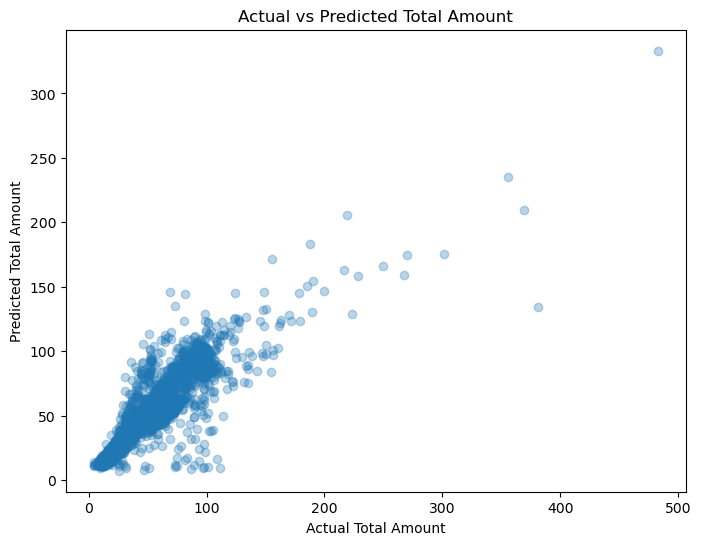

In [81]:
import matplotlib.pyplot as plt

# Use a sample to make the plot faster
sample_size = 5000

plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation[:sample_size],
    y_validation_pred[:sample_size],
    alpha=0.3
)

plt.xlabel("Actual Total Amount")
plt.ylabel("Predicted Total Amount")
plt.title("Actual vs Predicted Total Amount")

plt.show()

### Actual vs Predicted Results

The scatter plot shows a clear positive relationship between the actual and predicted `total_amount`.

Most predictions follow the general trend of the actual values, which shows that the Linear Regression model performs reasonably well.

However, the predictions become more spread out for higher trip amounts, which means the model has larger errors for some expensive trips.

In [82]:
# Calculate residuals
residuals = y_validation - y_validation_pred

# Check residual statistics
print(residuals.describe())

count    1.050317e+07
mean    -7.655777e-01
std      9.632886e+00
min     -3.135179e+02
25%     -3.525267e+00
50%     -7.914447e-01
75%      1.745470e+00
max      8.737439e+02
Name: total_amount, dtype: float64


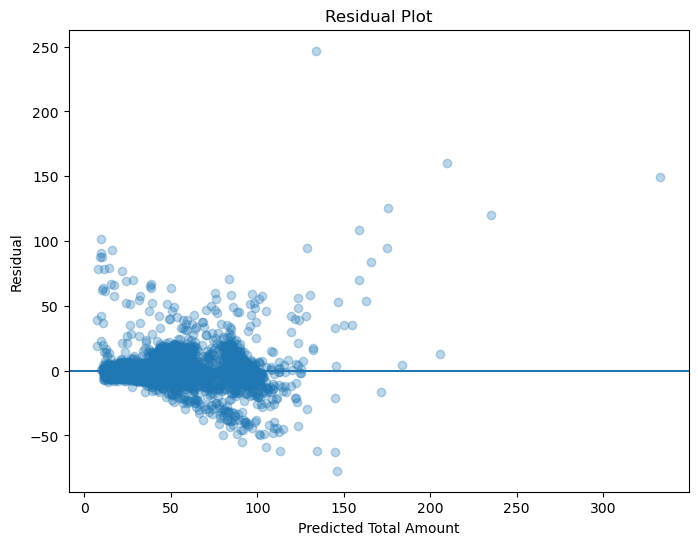

In [83]:
import matplotlib.pyplot as plt

sample_size = 5000

plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation_pred[:sample_size],
    residuals[:sample_size],
    alpha=0.3
)

plt.axhline(0)

plt.xlabel("Predicted Total Amount")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

### Residual Analysis

The residuals were calculated as the difference between the actual and predicted `total_amount`.

Most residuals are close to zero, which means that many predictions are reasonably accurate.

The average residual is about **-0.77**, showing that the model slightly overpredicts on average.

However, the residual plot also shows that the errors become larger for some higher-value trips.

This means the Linear Regression model performs reasonably well overall, but it is less accurate for some expensive trips.